In [120]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import pyarrow.dataset as ds

In [121]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print("Processed directory:", PROCESSED_DIR)
print("Exists:", PROCESSED_DIR.exists())

Processed directory: d:\Projects\ML_WORK\data\processed
Exists: True


In [122]:
parquet_files = sorted(PROCESSED_DIR.glob("*.parquet"))

print("Total Parquet files:", len(parquet_files))

Total Parquet files: 742


In [123]:
dataset = ds.dataset(
    PROCESSED_DIR,
    format="parquet"
)

print(dataset.schema)

episode_id: large_string
player: int64
step: int64
day: int64
hour: int64
money: double
farmer_x: int64
farmer_y: int64
hires_today: int64
remaining_overage_time: double
step_reward: double
status: large_string
final_reward: double
farmer_action: large_string
hands_action_count: int64
market_action_count: int64
carrot_price: int64
egg_price: int64
fertilizer_price: int64
melon_price: int64
milk_price: int64
strawberry_price: int64
tomato_price: int64
wheat_price: int64
wool_price: int64
carrot_seed: int64
melon_seed: int64
strawberry_seed: int64
tomato_seed: int64
wheat_seed: int64
shed_carrot: int64
shed_cow: int64
shed_egg: int64
shed_fertilizer: int64
shed_goose: int64
shed_melon: int64
shed_milk: int64
shed_sheep: int64
shed_strawberry: int64
shed_tomato: int64
shed_wheat: int64
shed_wool: int64
locked_tile_count: int64
empty_tile_count: int64
plant_tile_count: int64
pasture_tile_count: int64
weed_tile_count: int64
carrot_plant_count: int64
melon_plant_count: int64
strawberry_plant

In [124]:
total_rows = dataset.count_rows()

print("Total rows:", total_rows)

Total rows: 1068480


In [125]:
columns = dataset.schema.names

print("Total features:", len(columns))

for i, column in enumerate(columns, start=1):
    print(f"{i:02d}. {column}")

Total features: 64
01. episode_id
02. player
03. step
04. day
05. hour
06. money
07. farmer_x
08. farmer_y
09. hires_today
10. remaining_overage_time
11. step_reward
12. status
13. final_reward
14. farmer_action
15. hands_action_count
16. market_action_count
17. carrot_price
18. egg_price
19. fertilizer_price
20. melon_price
21. milk_price
22. strawberry_price
23. tomato_price
24. wheat_price
25. wool_price
26. carrot_seed
27. melon_seed
28. strawberry_seed
29. tomato_seed
30. wheat_seed
31. shed_carrot
32. shed_cow
33. shed_egg
34. shed_fertilizer
35. shed_goose
36. shed_melon
37. shed_milk
38. shed_sheep
39. shed_strawberry
40. shed_tomato
41. shed_wheat
42. shed_wool
43. locked_tile_count
44. empty_tile_count
45. plant_tile_count
46. pasture_tile_count
47. weed_tile_count
48. carrot_plant_count
49. melon_plant_count
50. strawberry_plant_count
51. tomato_plant_count
52. wheat_plant_count
53. cow_count
54. sheep_count
55. goose_count
56. total_plant_yield
57. total_pasture_yield
58. w

In [126]:
sample_df = pd.read_parquet(
    parquet_files[0]
)

print("Sample shape:", sample_df.shape)

sample_df.head()

Sample shape: (1440, 64)


,episode_id,player,step,day,hour,money,farmer_x,farmer_y,hires_today,remaining_overage_time,...,goose_count,total_plant_yield,total_pasture_yield,watered_plant_count,unwatered_plant_count,fertilized_plant_count,fed_animal_count,unfed_animal_count,cared_animal_count,uncared_animal_count
0,c6bc5296-9060-11f1-814b-0242ac130202,0,0,0,0,3000.0,4,4,0,60.00000,...,0,0,0,0,0,0,0,0,0,0
1,c6bc5296-9060-11f1-814b-0242ac130202,1,0,0,0,3000.0,4,4,0,60.00000,...,0,0,0,0,0,0,0,0,0,0
2,c6bc5296-9060-11f1-814b-0242ac130202,0,1,0,1,2058.0,4,4,2,60.00000,...,0,0,0,0,0,0,0,0,0,0
3,c6bc5296-9060-11f1-814b-0242ac130202,1,1,0,1,2058.0,4,4,2,57.12553,...,0,0,0,0,0,0,0,0,0,0
4,c6bc5296-9060-11f1-814b-0242ac130202,0,2,0,2,1442.0,4,4,3,60.00000,...,0,0,0,0,0,0,0,1,0,1


In [127]:
numeric_columns = sample_df.select_dtypes(
    include="number"
).columns.tolist()

categorical_columns = sample_df.select_dtypes(
    exclude="number"
).columns.tolist()

print("Numeric features:", len(numeric_columns))
print("Categorical/object features:", len(categorical_columns))

print("\nNumeric:")
print(numeric_columns)

print("\nCategorical/object:")
print(categorical_columns)

Numeric features: 61
Categorical/object features: 3

Numeric:
['player', 'step', 'day', 'hour', 'money', 'farmer_x', 'farmer_y', 'hires_today', 'remaining_overage_time', 'step_reward', 'final_reward', 'hands_action_count', 'market_action_count', 'carrot_price', 'egg_price', 'fertilizer_price', 'melon_price', 'milk_price', 'strawberry_price', 'tomato_price', 'wheat_price', 'wool_price', 'carrot_seed', 'melon_seed', 'strawberry_seed', 'tomato_seed', 'wheat_seed', 'shed_carrot', 'shed_cow', 'shed_egg', 'shed_fertilizer', 'shed_goose', 'shed_melon', 'shed_milk', 'shed_sheep', 'shed_strawberry', 'shed_tomato', 'shed_wheat', 'shed_wool', 'locked_tile_count', 'empty_tile_count', 'plant_tile_count', 'pasture_tile_count', 'weed_tile_count', 'carrot_plant_count', 'melon_plant_count', 'strawberry_plant_count', 'tomato_plant_count', 'wheat_plant_count', 'cow_count', 'sheep_count', 'goose_count', 'total_plant_yield', 'total_pasture_yield', 'watered_plant_count', 'unwatered_plant_count', 'fertilized

In [128]:
print("Status values:")
print(sample_df["status"].value_counts())

print("\nFarmer actions:")
print(sample_df["farmer_action"].value_counts().head(20))

Status values:
status
ACTIVE    1438
DONE         2
Name: count, dtype: int64

Farmer actions:
farmer_action
PICKUP,WHEAT,2         324
FEED                   224
WEST                   170
NORTH                  162
EAST                   156
SOUTH                  112
PASS                    92
WATER                   64
HARVEST                 30
COLLECT_FERTILIZER      20
CARE                    16
PICKUP,WHEAT,1          12
PLANT,WHEAT             10
FERTILIZE                8
BUILD_PASTURE            6
DROP                     6
PICKUP,WHEAT,8           6
PICKUP,FERTILIZER,4      6
PICKUP,COW,1             4
PLACE,COW                4
Name: count, dtype: int64


In [129]:
print("Step reward:")
print(sample_df["step_reward"].describe())

print("\nFinal reward:")
print(sample_df["final_reward"].describe())

Step reward:
count      1440.000000
mean        211.353472
std        5669.248525
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      152469.000000
Name: step_reward, dtype: float64

Final reward:
count      1440.00000
mean     152174.50000
std         294.60231
min      151880.00000
25%      151880.00000
50%      152174.50000
75%      152469.00000
max      152469.00000
Name: final_reward, dtype: float64


In [130]:
print(
    sample_df[
        ["player", "step_reward", "final_reward"]
    ].head(20)
)

    player  step_reward  final_reward
0        0          0.0      151880.0
1        1          0.0      152469.0
2        0          0.0      151880.0
3        1          0.0      152469.0
4        0          0.0      151880.0
5        1          0.0      152469.0
6        0          0.0      151880.0
7        1          0.0      152469.0
8        0          0.0      151880.0
9        1          0.0      152469.0
10       0          0.0      151880.0
11       1          0.0      152469.0
12       0          0.0      151880.0
13       1          0.0      152469.0
14       0          0.0      151880.0
15       1          0.0      152469.0
16       0          0.0      151880.0
17       1          0.0      152469.0
18       0          0.0      151880.0
19       1          0.0      152469.0


In [131]:
player_summary = (
    sample_df
    .groupby("player")
    .agg(
        mean_money=("money", "mean"),
        max_money=("money", "max"),
        total_step_reward=("step_reward", "sum"),
        final_reward=("final_reward", "first"),
    )
)

player_summary

,mean_money,max_money,total_step_reward,final_reward
player,,,,
0,38731.415278,151880.0,151880.0,151880.0
1,39207.969444,152469.0,152469.0,152469.0


In [132]:
sample_df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
player,1440.0,0.500000,0.500174,0.0,0.00,0.5,1.00,1.0
step,1440.0,359.500000,207.918103,0.0,179.75,359.5,539.25,719.0
day,1440.0,14.500000,8.658448,0.0,7.00,14.5,22.00,29.0
hour,1440.0,11.500000,6.924591,0.0,5.75,11.5,17.25,23.0
money,1440.0,38969.692361,45179.942606,4.0,782.25,18936.0,71203.75,152469.0
...,...,...,...,...,...,...,...,...
fertilized_plant_count,1440.0,35.629861,14.674976,0.0,19.00,39.0,50.00,55.0
fed_animal_count,1440.0,5.920833,4.999859,0.0,1.00,4.0,11.00,14.0
unfed_animal_count,1440.0,5.301389,5.003348,0.0,1.00,3.0,10.00,14.0
cared_animal_count,1440.0,6.818056,5.098224,0.0,2.00,6.0,12.00,14.0


In [133]:
for column in numeric_columns:
    min_value = sample_df[column].min()
    max_value = sample_df[column].max()

    print(
        f"{column:30s} "
        f"min={min_value} "
        f"max={max_value}"
    )

player                         min=0 max=1
step                           min=0 max=719
day                            min=0 max=29
hour                           min=0 max=23
money                          min=4.0 max=152469.0
farmer_x                       min=0 max=9
farmer_y                       min=0 max=8
hires_today                    min=0 max=12
remaining_overage_time         min=57.12553 max=60.0
step_reward                    min=0.0 max=152469.0
final_reward                   min=151880.0 max=152469.0
hands_action_count             min=0 max=12
market_action_count            min=0 max=10
carrot_price                   min=35 max=41
egg_price                      min=50 max=74
fertilizer_price               min=13 max=100
melon_price                    min=142 max=278
milk_price                     min=147 max=221
strawberry_price               min=120 max=241
tomato_price                   min=60 max=101
wheat_price                    min=25 max=58
wool_price              

In [134]:
constant_features = [
    column
    for column in numeric_columns
    if sample_df[column].nunique() <= 1
]

print("Constant features:")
print(constant_features)

Constant features:
['carrot_seed', 'tomato_seed', 'shed_carrot', 'shed_egg', 'shed_goose', 'shed_tomato', 'carrot_plant_count', 'tomato_plant_count', 'goose_count']


In [135]:
sample_df[
    [
        "step",
        "money",
        "step_reward",
        "final_reward"
    ]
].tail(20)

,step,money,step_reward,final_reward
1420,710,138499.0,0.0,151880.0
1421,710,139683.0,0.0,152469.0
1422,711,139322.0,0.0,151880.0
1423,711,140506.0,0.0,152469.0
1424,712,139322.0,0.0,151880.0
1425,712,140506.0,0.0,152469.0
1426,713,141854.0,0.0,151880.0
1427,713,143038.0,0.0,152469.0
1428,714,146357.0,0.0,151880.0
1429,714,146940.0,0.0,152469.0


In [136]:
print("Total rows:", total_rows)
print("Total features:", len(columns))
print(categorical_columns)
print(sample_df["farmer_action"].value_counts().head(20))
print(sample_df["final_reward"].describe())
print(constant_features)

Total rows: 1068480
Total features: 64
['episode_id', 'status', 'farmer_action']
farmer_action
PICKUP,WHEAT,2         324
FEED                   224
WEST                   170
NORTH                  162
EAST                   156
SOUTH                  112
PASS                    92
WATER                   64
HARVEST                 30
COLLECT_FERTILIZER      20
CARE                    16
PICKUP,WHEAT,1          12
PLANT,WHEAT             10
FERTILIZE                8
BUILD_PASTURE            6
DROP                     6
PICKUP,WHEAT,8           6
PICKUP,FERTILIZER,4      6
PICKUP,COW,1             4
PLACE,COW                4
Name: count, dtype: int64
count      1440.00000
mean     152174.50000
std         294.60231
min      151880.00000
25%      151880.00000
50%      152174.50000
75%      152469.00000
max      152469.00000
Name: final_reward, dtype: float64
['carrot_seed', 'tomato_seed', 'shed_carrot', 'shed_egg', 'shed_goose', 'shed_tomato', 'carrot_plant_count', 'tomato_plant_count

In [137]:
import pyarrow.dataset as ds
import pandas as pd

dataset = ds.dataset(
    PROCESSED_DIR,
    format="parquet"
)

# Load only the columns needed for this profiling pass
profile_columns = [
    "episode_id",
    "player",
    "step",
    "final_reward",
    "farmer_action",
]

profile_df = dataset.to_table(
    columns=profile_columns
).to_pandas()

print("Rows:", len(profile_df))
print("Unique episodes:", profile_df["episode_id"].nunique())
print("Unique final rewards:", profile_df["final_reward"].nunique())

Rows: 1068480
Unique episodes: 742
Unique final rewards: 1460


In [138]:
print(
    profile_df.groupby("player")["final_reward"]
    .agg(["count", "nunique", "min", "max", "mean"])
)

         count  nunique      min       max          mean
player                                                  
0       534240      739  68777.0  173012.0  123896.48248
1       534240      734  17733.0  169919.0  123880.62938


In [139]:
print(
    profile_df["final_reward"]
    .drop_duplicates()
    .describe()
)

count      1460.000000
mean     123859.674658
std       20689.481117
min       17733.000000
25%      108337.250000
50%      125895.000000
75%      140107.000000
max      173012.000000
Name: final_reward, dtype: float64


In [140]:
reward_by_episode = (
    profile_df
    .drop_duplicates(["episode_id", "player"])
    ["final_reward"]
)

print(reward_by_episode.describe())

count      1484.000000
mean     123888.555930
std       20627.910976
min       17733.000000
25%      108363.500000
50%      125855.000000
75%      140170.000000
max      173012.000000
Name: final_reward, dtype: float64


In [141]:
player_rewards = (
    profile_df
    .drop_duplicates(["episode_id", "player"])
    .groupby("player")["final_reward"]
    .agg(
        episodes="count",
        mean="mean",
        median="median",
        std="std",
        minimum="min",
        maximum="max"
    )
)

player_rewards

,episodes,mean,median,std,minimum,maximum
player,,,,,,
0,742,123896.48248,125570.5,20458.429774,68777.0,173012.0
1,742,123880.62938,125895.0,20809.809857,17733.0,169919.0


In [142]:
player_reward_table = (
    profile_df
    .drop_duplicates(["episode_id", "player"])
    .pivot(
        index="episode_id",
        columns="player",
        values="final_reward"
    )
    .rename(columns={
        0: "player_0_reward",
        1: "player_1_reward"
    })
)

player_reward_table["reward_difference"] = (
    player_reward_table["player_0_reward"]
    - player_reward_table["player_1_reward"]
)

player_reward_table.head()

player,player_0_reward,player_1_reward,reward_difference
episode_id,,,
00acc8b0-90fb-11f1-835c-0242ac130204,93082.0,95206.0,-2124.0
01d087ec-9126-11f1-90c8-0242ac130202,94524.0,94566.0,-42.0
01ec1736-90aa-11f1-8272-0242ac130203,157929.0,162550.0,-4621.0
021237a0-9126-11f1-a073-0242ac130203,151509.0,145424.0,6085.0
02247b58-90aa-11f1-84bd-0242ac130204,130058.0,133089.0,-3031.0


In [143]:
player_reward_table["reward_difference"].describe()

count       742.000000
mean         15.853100
std        8044.039034
min      -24189.000000
25%       -3125.750000
50%        -141.000000
75%        2662.000000
max      155279.000000
Name: reward_difference, dtype: float64

In [144]:
action_counts = (
    profile_df["farmer_action"]
    .value_counts()
)

print(action_counts.head(30))

farmer_action
NORTH                  145406
WEST                   134650
WATER                  115890
SOUTH                  115750
FEED                   107430
EAST                   100101
PICKUP,WHEAT,2          88815
PASS                    71780
HARVEST                 47086
COLLECT_FERTILIZER      38453
CARE                    24626
DROP                    13824
PICKUP,WHEAT,14          9854
FERTILIZE                6698
PLANT,WHEAT              6327
BUILD_PASTURE            6257
PLANT,MELON              5719
PICKUP,WHEAT,1           4929
PLANT,STRAWBERRY         3969
PICKUP,WHEAT,4           3778
DIG                      2788
PICKUP,FERTILIZER,2      2589
PICKUP,WHEAT,12          1825
PICKUP,WHEAT,6           1795
PICKUP,WHEAT,8           1593
PICKUP,FERTILIZER,4      1587
PICKUP,WHEAT,3           1205
PLACE,COW                1196
PICKUP,COW,1             1097
PLACE,SHEEP               637
Name: count, dtype: int64


In [145]:
print("Unique farmer actions:", profile_df["farmer_action"].nunique())

Unique farmer actions: 41


In [146]:
actions_by_player = (
    profile_df
    .groupby("player")["farmer_action"]
    .value_counts()
)

print(actions_by_player.head(30))

player  farmer_action      
0       NORTH                  73230
        WEST                   67401
        WATER                  59118
        SOUTH                  58408
        FEED                   52795
        EAST                   49657
        PICKUP,WHEAT,2         42376
        PASS                   35985
        HARVEST                23932
        COLLECT_FERTILIZER     19443
        CARE                   12263
        DROP                    7014
        PICKUP,WHEAT,14         5118
        FERTILIZE               3373
        PLANT,WHEAT             3167
        BUILD_PASTURE           3165
        PLANT,MELON             2920
        PICKUP,WHEAT,1          2417
        PLANT,STRAWBERRY        2018
        PICKUP,WHEAT,4          1930
        DIG                     1449
        PICKUP,FERTILIZER,2     1347
        PICKUP,WHEAT,12          947
        PICKUP,WHEAT,6           932
        PICKUP,WHEAT,8           756
        PICKUP,FERTILIZER,4      753
        PL

In [147]:
profile_df["action_type"] = (
    profile_df["farmer_action"]
    .str.split(",")
    .str[0]
)

In [148]:
print(
    profile_df["action_type"]
    .value_counts()
)

action_type
NORTH                 145406
WEST                  134650
PICKUP                119889
WATER                 115890
SOUTH                 115750
FEED                  107430
EAST                  100101
PASS                   71780
HARVEST                47086
COLLECT_FERTILIZER     38453
CARE                   24626
PLANT                  16019
DROP                   13824
FERTILIZE               6698
BUILD_PASTURE           6257
DIG                     2788
PLACE                   1833
Name: count, dtype: int64


In [149]:
action_reward = (
    profile_df
    .groupby("action_type")["final_reward"]
    .agg(
        count="count",
        mean_reward="mean",
        median_reward="median"
    )
    .sort_values("mean_reward", ascending=False)
)

action_reward

,count,mean_reward,median_reward
action_type,,,
PICKUP,119889,125139.607979,128287.0
FEED,107430,124436.767346,126949.0
PLACE,1833,124036.004910,127095.0
EAST,100101,123971.972777,126038.0
WEST,134650,123833.790702,125761.0
FERTILIZE,6698,123797.972231,125748.0
PLANT,16019,123767.678632,125447.0
NORTH,145406,123752.867199,125638.0
BUILD_PASTURE,6257,123649.932396,125432.0


In [150]:
numeric_df = dataset.to_table(
    columns=[
        "player",
        "step",
        "day",
        "hour",
        "money",
        "farmer_x",
        "farmer_y",
        "hires_today",
        "remaining_overage_time",
        "step_reward",
        "final_reward",
        "hands_action_count",
        "market_action_count",

        "carrot_price",
        "egg_price",
        "fertilizer_price",
        "melon_price",
        "milk_price",
        "strawberry_price",
        "tomato_price",
        "wheat_price",
        "wool_price",

        "carrot_seed",
        "melon_seed",
        "strawberry_seed",
        "tomato_seed",
        "wheat_seed",

        "shed_carrot",
        "shed_cow",
        "shed_egg",
        "shed_fertilizer",
        "shed_goose",
        "shed_melon",
        "shed_milk",
        "shed_sheep",
        "shed_strawberry",
        "shed_tomato",
        "shed_wheat",
        "shed_wool",

        "locked_tile_count",
        "empty_tile_count",
        "plant_tile_count",
        "pasture_tile_count",
        "weed_tile_count",

        "carrot_plant_count",
        "melon_plant_count",
        "strawberry_plant_count",
        "tomato_plant_count",
        "wheat_plant_count",

        "cow_count",
        "sheep_count",
        "goose_count",

        "total_plant_yield",
        "total_pasture_yield",

        "watered_plant_count",
        "unwatered_plant_count",
        "fertilized_plant_count",

        "fed_animal_count",
        "unfed_animal_count",
        "cared_animal_count",
        "uncared_animal_count",
    ]
).to_pandas()

print(numeric_df.shape)

(1068480, 61)


In [151]:
reward_correlation = (
    numeric_df
    .corr(numeric_only=True)["final_reward"]
    .sort_values(ascending=False)
)

print(reward_correlation)

final_reward          1.000000
milk_price            0.566119
strawberry_price      0.259199
money                 0.121648
wool_price            0.057200
                        ...   
shed_egg                   NaN
shed_goose                 NaN
shed_tomato                NaN
tomato_plant_count         NaN
goose_count                NaN
Name: final_reward, Length: 61, dtype: float64


In [152]:
top_correlations = (
    reward_correlation
    .drop("final_reward")
    .abs()
    .sort_values(ascending=False)
)

print(top_correlations.head(15))


milk_price                0.566119
strawberry_price          0.259199
egg_price                 0.137430
money                     0.121648
carrot_price              0.107743
wool_price                0.057200
shed_sheep                0.048285
strawberry_seed           0.030831
remaining_overage_time    0.026300
carrot_plant_count        0.022981
uncared_animal_count      0.021978
empty_tile_count          0.018427
shed_cow                  0.018236
sheep_count               0.016535
carrot_seed               0.015149
Name: final_reward, dtype: float64


In [153]:
profile_for_episode = dataset.to_table(
    columns=[
        "episode_id",
        "player",
        "step",
        "day",
        "hour",
        "money",
        "farmer_x",
        "farmer_y",
        "hires_today",
        "remaining_overage_time",
        "step_reward",
        "final_reward",
        "hands_action_count",
        "market_action_count",
        "plant_tile_count",
        "pasture_tile_count",
        "weed_tile_count",
        "watered_plant_count",
        "fertilized_plant_count",
        "fed_animal_count",
        "cared_animal_count",
    ]
).to_pandas()

print(profile_for_episode.shape)
print(profile_for_episode.columns.tolist())

(1068480, 21)
['episode_id', 'player', 'step', 'day', 'hour', 'money', 'farmer_x', 'farmer_y', 'hires_today', 'remaining_overage_time', 'step_reward', 'final_reward', 'hands_action_count', 'market_action_count', 'plant_tile_count', 'pasture_tile_count', 'weed_tile_count', 'watered_plant_count', 'fertilized_plant_count', 'fed_animal_count', 'cared_animal_count']


In [154]:
episode_level = (
    profile_for_episode
    .groupby(["episode_id", "player"], as_index=False)
    .agg(
        final_reward=("final_reward", "first"),
        mean_money=("money", "mean"),
        max_money=("money", "max"),
        final_money=("money", "last"),
        total_step_reward=("step_reward", "sum"),
        mean_step_reward=("step_reward", "mean"),
        max_step_reward=("step_reward", "max"),
        mean_plant_count=("plant_tile_count", "mean"),
        max_plant_count=("plant_tile_count", "max"),
        mean_pasture_count=("pasture_tile_count", "mean"),
        max_pasture_count=("pasture_tile_count", "max"),
        mean_weed_count=("weed_tile_count", "mean"),
        max_weed_count=("weed_tile_count", "max"),
        mean_watered_plants=("watered_plant_count", "mean"),
        mean_fertilized_plants=("fertilized_plant_count", "mean"),
        mean_fed_animals=("fed_animal_count", "mean"),
        mean_cared_animals=("cared_animal_count", "mean"),
        total_hands_actions=("hands_action_count", "sum"),
        total_market_actions=("market_action_count", "sum"),
    )
)

print("Episode-level shape:", episode_level.shape)
episode_level.head()

Episode-level shape: (1484, 21)


,episode_id,player,final_reward,mean_money,max_money,final_money,total_step_reward,mean_step_reward,max_step_reward,mean_plant_count,...,mean_pasture_count,max_pasture_count,mean_weed_count,max_weed_count,mean_watered_plants,mean_fertilized_plants,mean_fed_animals,mean_cared_animals,total_hands_actions,total_market_actions
0,00acc8b0-90fb-11f1-835c-0242ac130204,0,93082.0,27126.529167,93082.0,93082.0,93082.0,129.280556,93082.0,37.377778,...,11.297222,14,1.388889,13,10.065278,37.377778,7.341667,5.706944,6024,752
1,00acc8b0-90fb-11f1-835c-0242ac130204,1,95206.0,27594.027778,95206.0,95206.0,95206.0,132.230556,95206.0,36.745833,...,11.297222,14,2.062500,16,9.900000,36.745833,7.336111,5.654167,5947,745
2,01d087ec-9126-11f1-90c8-0242ac130202,0,94524.0,28316.509722,94524.0,94524.0,94524.0,131.283333,94524.0,41.734722,...,11.738889,14,0.526389,14,12.165278,41.734722,7.431944,7.204167,6097,888
3,01d087ec-9126-11f1-90c8-0242ac130202,1,94566.0,29681.766667,94566.0,94566.0,94566.0,131.341667,94566.0,32.393056,...,14.591667,18,6.813889,42,11.537500,32.393056,7.998611,4.908333,6824,857
4,01ec1736-90aa-11f1-8272-0242ac130203,0,157929.0,39213.593056,157929.0,157929.0,157929.0,219.345833,157929.0,35.394444,...,11.222222,14,1.884722,19,8.586111,35.394444,5.920833,6.818056,6614,1204


In [155]:
episode_correlations = (
    episode_level
    .select_dtypes(include="number")
    .corr()["final_reward"]
    .drop("final_reward")
    .sort_values(ascending=False)
)

print(episode_correlations)

max_money                 1.000000
total_step_reward         1.000000
final_money               1.000000
mean_step_reward          1.000000
max_step_reward           1.000000
mean_money                0.930612
mean_cared_animals        0.096101
mean_fertilized_plants    0.083126
mean_plant_count          0.083126
total_market_actions      0.064544
max_plant_count           0.040913
total_hands_actions       0.030123
player                   -0.000384
max_weed_count           -0.023197
mean_weed_count          -0.047018
mean_watered_plants      -0.048470
mean_fed_animals         -0.051994
max_pasture_count        -0.065685
mean_pasture_count       -0.070191
Name: final_reward, dtype: float64


In [156]:
# Features that are obviously unavailable before the episode ends
leakage_candidates = [
    "final_reward",
    "final_money",
    "total_step_reward",
]

print(leakage_candidates)

['final_reward', 'final_money', 'total_step_reward']


In [157]:
for feature in leakage_candidates:
    if feature in episode_level.columns:
        corr = episode_level[feature].corr(
            episode_level["final_reward"]
        )
        print(f"{feature}: {corr:.4f}")

final_reward: 1.0000
final_money: 1.0000
total_step_reward: 1.0000


In [158]:
# Numeric feature distributions / summary
state_numeric_columns = [
    col for col in numeric_df.columns
    if col not in [
        "player",
        "step",
        "day",
        "hour",
        "step_reward",
        "final_reward"
    ]
]

summary = numeric_df[state_numeric_columns].describe().T

summary["unique_values"] = (
    numeric_df[state_numeric_columns]
    .nunique()
)

summary["missing_values"] = (
    numeric_df[state_numeric_columns]
    .isnull()
    .sum()
)

summary.sort_values("unique_values").head(20)

,count,mean,std,min,25%,50%,75%,max,unique_values,missing_values
shed_goose,1068480.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,1,0
shed_tomato,1068480.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,1,0
shed_egg,1068480.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,1,0
tomato_seed,1068480.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,1,0
tomato_plant_count,1068480.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,1,0
goose_count,1068480.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,1,0
locked_tile_count,1068480.0,39.009925,21.932152,0.0,25.0,25.0,50.0,75.0,4,0
carrot_seed,1068480.0,0.002690,0.060169,0.0,0.0,0.0,0.0,4.0,5,0
shed_carrot,1068480.0,0.000086,0.017197,0.0,0.0,0.0,0.0,6.0,5,0
carrot_plant_count,1068480.0,0.007267,0.116985,0.0,0.0,0.0,0.0,5.0,6,0


In [159]:
high_variance = (
    summary
    .sort_values("std", ascending=False)
)

high_variance.head(20)


,count,mean,std,min,25%,50%,75%,max,unique_values,missing_values
money,1068480.0,34349.085860,38652.433542,0.0,827.0,19963.0,60014.0,173012.0,124456,0
milk_price,1068480.0,161.704219,63.864508,1.0,126.0,183.0,207.0,300.0,198,0
wool_price,1068480.0,192.353579,62.098792,1.0,196.0,217.0,230.0,246.0,91,0
melon_price,1068480.0,217.110134,55.553028,1.0,204.0,219.0,268.0,278.0,151,0
strawberry_price,1068480.0,174.679665,50.326318,1.0,148.0,182.0,212.0,267.0,192,0
fertilizer_price,1068480.0,62.411476,27.460866,1.0,39.0,63.0,90.0,100.0,100,0
locked_tile_count,1068480.0,39.009925,21.932152,0.0,25.0,25.0,50.0,75.0,4,0
total_plant_yield,1068480.0,35.563423,17.063467,0.0,23.0,32.0,47.0,130.0,124,0
shed_wheat,1068480.0,22.511644,16.806326,0.0,11.0,19.0,31.0,100.0,101,0
unwatered_plant_count,1068480.0,26.795965,15.976845,0.0,15.0,26.0,40.0,63.0,64,0


In [160]:
range_check = summary[
    ["min", "max", "mean", "std"]
].copy()

range_check["range"] = (
    range_check["max"] - range_check["min"]
)

range_check.sort_values(
    "range",
    ascending=False
).head(20)

,min,max,mean,std,range
money,0.0,173012.0,34349.085860,38652.433542,173012.0
milk_price,1.0,300.0,161.704219,63.864508,299.0
melon_price,1.0,278.0,217.110134,55.553028,277.0
strawberry_price,1.0,267.0,174.679665,50.326318,266.0
wool_price,1.0,246.0,192.353579,62.098792,245.0
total_plant_yield,0.0,130.0,35.563423,17.063467,130.0
shed_wheat,0.0,100.0,22.511644,16.806326,100.0
fertilizer_price,1.0,100.0,62.411476,27.460866,99.0
locked_tile_count,0.0,75.0,39.009925,21.932152,75.0
plant_tile_count,0.0,63.0,36.282776,15.342775,63.0


<Axes: title={'center': 'Money over episode steps'}, xlabel='Step', ylabel='Mean money'>

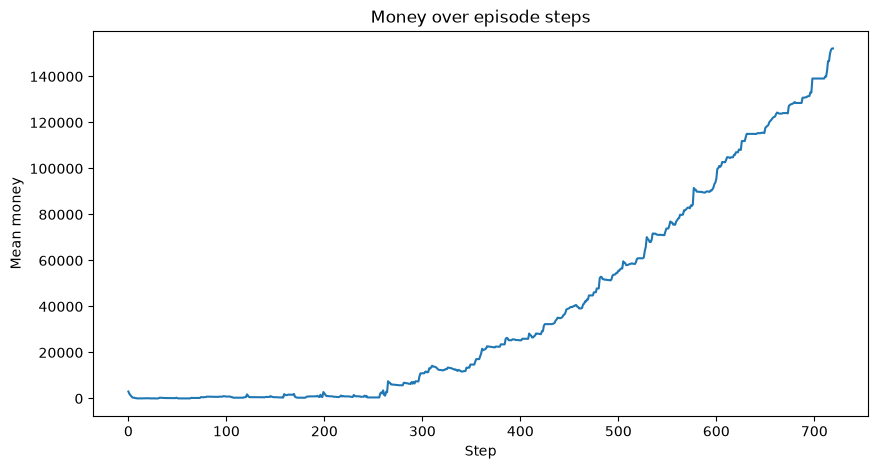

In [161]:
episode_sample = (
    profile_for_episode[
        profile_for_episode["episode_id"]
        == profile_for_episode["episode_id"].iloc[0]
    ]
)

episode_sample.groupby("step")["money"].mean().plot(
    figsize=(10, 5),
    title="Money over episode steps",
    xlabel="Step",
    ylabel="Mean money"
)

In [162]:
model_columns = [
    "episode_id",
    "player",
    "step",
    "day",
    "hour",
    "money",
    "farmer_x",
    "farmer_y",
    "hires_today",
    "remaining_overage_time",
    
    # Market
    "carrot_price",
    "egg_price",
    "fertilizer_price",
    "melon_price",
    "milk_price",
    "strawberry_price",
    "tomato_price",
    "wheat_price",
    "wool_price",

    # Seeds
    "carrot_seed",
    "melon_seed",
    "strawberry_seed",
    "tomato_seed",
    "wheat_seed",

    # Shed
    "shed_carrot",
    "shed_cow",
    "shed_egg",
    "shed_fertilizer",
    "shed_goose",
    "shed_melon",
    "shed_milk",
    "shed_sheep",
    "shed_strawberry",
    "shed_tomato",
    "shed_wheat",
    "shed_wool",

    # Farm / tile state
    "locked_tile_count",
    "empty_tile_count",
    "plant_tile_count",
    "pasture_tile_count",
    "weed_tile_count",
    "carrot_plant_count",
    "melon_plant_count",
    "strawberry_plant_count",
    "tomato_plant_count",
    "wheat_plant_count",
    "cow_count",
    "sheep_count",
    "goose_count",
    "total_plant_yield",
    "total_pasture_yield",
    "watered_plant_count",
    "unwatered_plant_count",
    "fertilized_plant_count",
    "fed_animal_count",
    "unfed_animal_count",
    "cared_animal_count",
    "uncared_animal_count",

    # Target
    "final_reward",
]

In [163]:
model_df = dataset.to_table(
    columns=model_columns
).to_pandas()

print("Shape:", model_df.shape)

Shape: (1068480, 59)


In [164]:
X = model_df.drop(
    columns=["episode_id", "final_reward"]
)

y = model_df["final_reward"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1068480, 57)
y shape: (1068480,)


In [165]:
from sklearn.model_selection import GroupShuffleSplit

groups = model_df["episode_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))

print(
    "Train episodes:",
    groups_train.nunique()
)

print(
    "Test episodes:",
    groups_test.nunique()
)

Train rows: 853920
Test rows: 214560
Train episodes: 593
Test episodes: 149


In [166]:
overlap = set(
    groups_train.unique()
).intersection(
    set(groups_test.unique())
)

print("Episode overlap:", len(overlap))

Episode overlap: 0


# Baseline ML Model


In [167]:
# Baseline ML Model
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [168]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [169]:
y_pred = model.predict(X_test)

In [170]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Baseline Random Forest")
print("----------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Baseline Random Forest
----------------------
MAE : 8353.620911191165
RMSE: 13717.157996866183
R²  : 0.5888863343076398


In [171]:
feature_importance = (
    pd.Series(
        model.feature_importances_,
        index=X_train.columns
    )
    .sort_values(ascending=False)
)

print(feature_importance.head(20))

milk_price                0.453992
strawberry_price          0.131178
money                     0.130579
wool_price                0.074144
egg_price                 0.026799
tomato_price              0.019262
step                      0.016636
remaining_overage_time    0.013660
carrot_price              0.012894
fertilizer_price          0.012704
melon_price               0.012150
wheat_price               0.011030
player                    0.009049
strawberry_plant_count    0.007849
shed_wheat                0.007799
melon_plant_count         0.004898
pasture_tile_count        0.004877
empty_tile_count          0.004672
total_plant_yield         0.004615
weed_tile_count           0.003636
dtype: float64


In [172]:
feature_importance = (
    pd.Series(
        model.feature_importances_,
        index=X_train.columns
    )
    .sort_values(ascending=False)
)

print(feature_importance.head(20))

milk_price                0.453992
strawberry_price          0.131178
money                     0.130579
wool_price                0.074144
egg_price                 0.026799
tomato_price              0.019262
step                      0.016636
remaining_overage_time    0.013660
carrot_price              0.012894
fertilizer_price          0.012704
melon_price               0.012150
wheat_price               0.011030
player                    0.009049
strawberry_plant_count    0.007849
shed_wheat                0.007799
melon_plant_count         0.004898
pasture_tile_count        0.004877
empty_tile_count          0.004672
total_plant_yield         0.004615
weed_tile_count           0.003636
dtype: float64


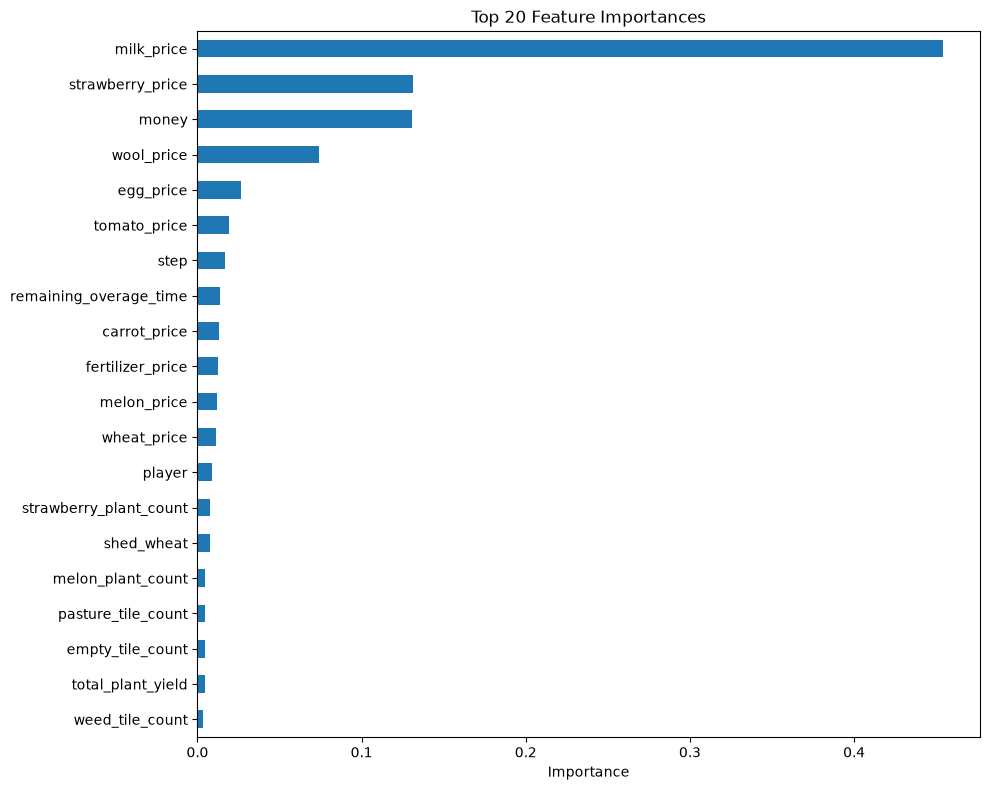

In [173]:
import matplotlib.pyplot as plt

feature_importance.head(20).sort_values().plot(
    kind="barh",
    figsize=(10, 8)
)

plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

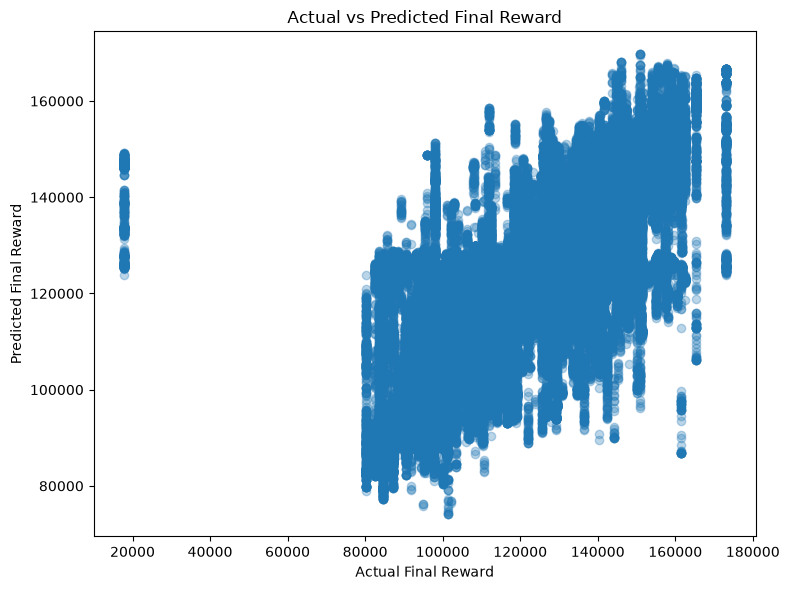

In [174]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.xlabel("Actual Final Reward")
plt.ylabel("Predicted Final Reward")
plt.title("Actual vs Predicted Final Reward")

plt.tight_layout()
plt.show()

In [175]:
results = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred
})

results["error"] = (
    results["actual"] - results["predicted"]
)

results["absolute_error"] = results["error"].abs()

print(results.head())
print("\nMean absolute error:")
print(results["absolute_error"].mean())

     actual      predicted        error  absolute_error
0  128973.0  123817.087946  5155.912054     5155.912054
1  132219.0  123926.575146  8292.424854     8292.424854
2  128973.0  127574.744081  1398.255919     1398.255919
3  132219.0  126730.975255  5488.024745     5488.024745
4  128973.0  127560.688911  1412.311089     1412.311089

Mean absolute error:
8353.620911191165


In [176]:
print(
    "Unique training rewards:",
    y_train.nunique()
)

print(
    "Unique test rewards:",
    y_test.nunique()
)

Unique training rewards: 1168
Unique test rewards: 297


In [177]:
print(
    "Unique rewards overall:",
    y.nunique()
)

Unique rewards overall: 1460


In [178]:
print("Unique rewards overall:", y.nunique())
print("\nReward frequency:")
print(
    y.value_counts()
     .sort_index()
     .head(30)
)

Unique rewards overall: 1460

Reward frequency:
final_reward
17733.0    720
68716.0    720
68777.0    720
69215.0    720
69552.0    720
71902.0    720
73452.0    720
74253.0    720
76929.0    720
77219.0    720
77265.0    720
78239.0    720
78663.0    720
80241.0    720
80339.0    720
80534.0    720
80868.0    720
81168.0    720
81176.0    720
81320.0    720
81797.0    720
82424.0    720
82496.0    720
82688.0    720
82820.0    720
83480.0    720
83707.0    720
84375.0    720
84589.0    720
84833.0    720
Name: count, dtype: int64


In [179]:
print("Minimum reward:", y.min())
print("Maximum reward:", y.max())
print("Mean reward:", y.mean())
print("Std reward:", y.std())


Minimum reward: 17733.0
Maximum reward: 173012.0
Mean reward: 123888.55592991914
Std reward: 20620.969349481224


In [180]:
reward_levels = (
    model_df[["episode_id", "player", "final_reward"]]
    .drop_duplicates()
)

print("Episode-player outcomes:", len(reward_levels))
print("Unique reward levels:", reward_levels["final_reward"].nunique())

print(
    reward_levels["final_reward"]
    .value_counts()
    .sort_index()
)

Episode-player outcomes: 1484
Unique reward levels: 1460
final_reward
17733.0     1
68716.0     1
68777.0     1
69215.0     1
69552.0     1
           ..
167265.0    1
168370.0    1
168401.0    1
169919.0    1
173012.0    1
Name: count, Length: 1460, dtype: int64


In [181]:
reward_levels = (
    model_df[["episode_id", "player", "final_reward"]]
    .drop_duplicates()
)

print("Episode-player outcomes:", len(reward_levels))
print("Unique reward levels:", reward_levels["final_reward"].nunique())

print("\nReward distribution:")
print(
    reward_levels["final_reward"]
    .value_counts()
    .sort_index()
)

Episode-player outcomes: 1484
Unique reward levels: 1460

Reward distribution:
final_reward
17733.0     1
68716.0     1
68777.0     1
69215.0     1
69552.0     1
           ..
167265.0    1
168370.0    1
168401.0    1
169919.0    1
173012.0    1
Name: count, Length: 1460, dtype: int64


In [182]:
reward_levels["final_reward"].describe()

count      1484.000000
mean     123888.555930
std       20627.910976
min       17733.000000
25%      108363.500000
50%      125855.000000
75%      140170.000000
max      173012.000000
Name: final_reward, dtype: float64

In [183]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_prediction = np.full(
    shape=len(y_test),
    fill_value=y_train.mean()
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_prediction
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_prediction
)

print("Mean baseline")
print("----------------")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)
print("R²  :", baseline_r2)


Mean baseline
----------------
MAE : 17808.368295664182
RMSE: 21400.154389702697
R²  : -0.000616003230601736


In [184]:
print("Random Forest")
print("----------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Random Forest
----------------
MAE : 8353.620911191165
RMSE: 13717.157996866183
R²  : 0.5888863343076398


In [185]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_prediction = np.full(
    len(y_test),
    y_train.mean()
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_prediction
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_prediction
)

print("Mean baseline")
print("----------------")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)
print("R²  :", baseline_r2)

Mean baseline
----------------
MAE : 17808.368295664182
RMSE: 21400.154389702697
R²  : -0.000616003230601736


In [186]:
print("Mean baseline")
print("----------------")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)
print("R²  :", baseline_r2)

print("\nRandom Forest")
print("----------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Mean baseline
----------------
MAE : 17808.368295664182
RMSE: 21400.154389702697
R²  : -0.000616003230601736

Random Forest
----------------
MAE : 8353.620911191165
RMSE: 13717.157996866183
R²  : 0.5888863343076398


In [187]:
improvement_mae = (
    (baseline_mae - mae) / baseline_mae * 100
)

improvement_rmse = (
    (baseline_rmse - rmse) / baseline_rmse * 100
)

print("MAE improvement :", improvement_mae, "%")
print("RMSE improvement:", improvement_rmse, "%")

MAE improvement : 53.09159844125063 %
RMSE improvement: 35.90159329193162 %


In [188]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Mean prediction baseline
baseline_prediction = np.full(
    len(y_test),
    y_train.mean()
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_prediction
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_prediction
)

print("Mean Baseline")
print("-------------")
print(f"MAE : {baseline_mae:.2f}")
print(f"RMSE: {baseline_rmse:.2f}")
print(f"R²  : {baseline_r2:.4f}")

print("\nRandom Forest")
print("-------------")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

mae_improvement = (
    (baseline_mae - mae) / baseline_mae * 100
)

rmse_improvement = (
    (baseline_rmse - rmse) / baseline_rmse * 100
)

print("\nImprovement over baseline")
print("-------------------------")
print(f"MAE improvement : {mae_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")

Mean Baseline
-------------
MAE : 17808.37
RMSE: 21400.15
R²  : -0.0006

Random Forest
-------------
MAE : 8353.62
RMSE: 13717.16
R²  : 0.5889

Improvement over baseline
-------------------------
MAE improvement : 53.09%
RMSE improvement: 35.90%


In [189]:
feature_importance = (
    pd.Series(
        model.feature_importances_,
        index=X_train.columns
    )
    .sort_values(ascending=False)
)

print(feature_importance.head(20))


milk_price                0.453992
strawberry_price          0.131178
money                     0.130579
wool_price                0.074144
egg_price                 0.026799
tomato_price              0.019262
step                      0.016636
remaining_overage_time    0.013660
carrot_price              0.012894
fertilizer_price          0.012704
melon_price               0.012150
wheat_price               0.011030
player                    0.009049
strawberry_plant_count    0.007849
shed_wheat                0.007799
melon_plant_count         0.004898
pasture_tile_count        0.004877
empty_tile_count          0.004672
total_plant_yield         0.004615
weed_tile_count           0.003636
dtype: float64


In [190]:
print("Milk price unique values:")
print(model_df["milk_price"].nunique())

print("\nMilk price distribution:")
print(model_df["milk_price"].value_counts().sort_index())

Milk price unique values:
198

Milk price distribution:
milk_price
1      4200
3      1816
5      5674
7      2840
9      6568
       ... 
296      18
297      24
298       2
299       8
300       2
Name: count, Length: 198, dtype: int64


In [191]:
milk_reward = (
    model_df
    .groupby("milk_price")["final_reward"]
    .agg(
        count="count",
        mean_reward="mean",
        median_reward="median"
    )
)

milk_reward

,count,mean_reward,median_reward
milk_price,,,
1,4200,101901.726429,100552.0
3,1816,101213.229626,100024.0
5,5674,102052.265245,100514.0
7,2840,101827.015845,100238.0
9,6568,102580.388094,101673.0
...,...,...,...
296,18,95372.500000,95372.5
297,24,95372.500000,95372.5
298,2,95372.500000,95372.5


In [192]:
milk_episode = (
    model_df[
        ["episode_id", "player", "milk_price", "final_reward"]
    ]
    .groupby(
        ["episode_id", "player"],
        as_index=False
    )
    .agg(
        mean_milk_price=("milk_price", "mean"),
        final_milk_price=("milk_price", "last"),
        final_reward=("final_reward", "first")
    )
)

print(
    milk_episode[
        ["mean_milk_price", "final_milk_price", "final_reward"]
    ].corr()
)

                  mean_milk_price  final_milk_price  final_reward
mean_milk_price          1.000000          0.949220      0.778043
final_milk_price         0.949220          1.000000      0.740021
final_reward             0.778043          0.740021      1.000000


In [193]:
top_features = [
    "milk_price",
    "strawberry_price",
    "money",
    "wool_price",
    "egg_price",
]

print(
    model_df[top_features + ["final_reward"]]
    .corr(numeric_only=True)["final_reward"]
    .sort_values(ascending=False)
)

final_reward        1.000000
milk_price          0.566119
strawberry_price    0.259199
money               0.121648
wool_price          0.057200
egg_price          -0.137430
Name: final_reward, dtype: float64


In [194]:
print("Unique milk prices:", model_df["milk_price"].nunique())

print("\nMilk price distribution:")
print(
    model_df["milk_price"]
    .value_counts()
    .sort_index()
)

Unique milk prices: 198

Milk price distribution:
milk_price
1      4200
3      1816
5      5674
7      2840
9      6568
       ... 
296      18
297      24
298       2
299       8
300       2
Name: count, Length: 198, dtype: int64


In [195]:
milk_reward = (
    model_df
    .groupby("milk_price")["final_reward"]
    .agg(
        count="count",
        mean_reward="mean",
        median_reward="median"
    )
)

milk_reward

,count,mean_reward,median_reward
milk_price,,,
1,4200,101901.726429,100552.0
3,1816,101213.229626,100024.0
5,5674,102052.265245,100514.0
7,2840,101827.015845,100238.0
9,6568,102580.388094,101673.0
...,...,...,...
296,18,95372.500000,95372.5
297,24,95372.500000,95372.5
298,2,95372.500000,95372.5


In [196]:
milk_episode = (
    model_df[
        [
            "episode_id",
            "player",
            "milk_price",
            "final_reward"
        ]
    ]
    .groupby(
        ["episode_id", "player"],
        as_index=False
    )
    .agg(
        mean_milk_price=("milk_price", "mean"),
        final_milk_price=("milk_price", "last"),
        final_reward=("final_reward", "first")
    )
)

print(
    milk_episode[
        [
            "mean_milk_price",
            "final_milk_price",
            "final_reward"
        ]
    ].corr()
)

                  mean_milk_price  final_milk_price  final_reward
mean_milk_price          1.000000          0.949220      0.778043
final_milk_price         0.949220          1.000000      0.740021
final_reward             0.778043          0.740021      1.000000


In [197]:
checkpoints = [0, 100, 300, 500, 700]

for checkpoint in checkpoints:
    checkpoint_df = model_df[
        model_df["step"] == checkpoint
    ].copy()

    print(
        f"Step {checkpoint}: "
        f"{len(checkpoint_df)} rows"
    )

Step 0: 1484 rows
Step 100: 1484 rows
Step 300: 1484 rows
Step 500: 1484 rows
Step 700: 1484 rows


In [198]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

checkpoints = [0, 100, 300, 500, 700]

results = []

feature_columns = [
    col for col in model_df.columns
    if col not in [
        "episode_id",
        "final_reward"
    ]
]

for checkpoint in checkpoints:

    checkpoint_df = model_df[
        model_df["step"] == checkpoint
    ].copy()

    X_checkpoint = checkpoint_df[feature_columns]
    y_checkpoint = checkpoint_df["final_reward"]
    groups_checkpoint = checkpoint_df["episode_id"]

    # Use the same episode split logic
    train_mask = groups_checkpoint.isin(
        groups_train.unique()
    )

    test_mask = groups_checkpoint.isin(
        groups_test.unique()
    )

    X_train_cp = X_checkpoint[train_mask]
    X_test_cp = X_checkpoint[test_mask]

    y_train_cp = y_checkpoint[train_mask]
    y_test_cp = y_checkpoint[test_mask]

    model_cp = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    model_cp.fit(
        X_train_cp,
        y_train_cp
    )

    predictions = model_cp.predict(X_test_cp)

    mae_cp = mean_absolute_error(
        y_test_cp,
        predictions
    )

    rmse_cp = np.sqrt(
        mean_squared_error(
            y_test_cp,
            predictions
        )
    )

    r2_cp = r2_score(
        y_test_cp,
        predictions
    )

    results.append({
        "step": checkpoint,
        "train_rows": len(X_train_cp),
        "test_rows": len(X_test_cp),
        "MAE": mae_cp,
        "RMSE": rmse_cp,
        "R2": r2_cp
    })

checkpoint_results = pd.DataFrame(results)

checkpoint_results

,step,train_rows,test_rows,MAE,RMSE,R2
0,0,1186,298,17804.096158,21402.844239,-0.000868
1,100,1186,298,13698.045414,17943.858092,0.296498
2,300,1186,298,6958.350232,10987.321336,0.736235
3,500,1186,298,3636.602718,6658.861030,0.903120
4,700,1186,298,1003.361510,3635.205749,0.971127


In [199]:
print(
    checkpoint_results[
        ["step", "MAE", "RMSE", "R2"]
    ].to_string(index=False)
)

 step          MAE         RMSE        R2
    0 17804.096158 21402.844239 -0.000868
  100 13698.045414 17943.858092  0.296498
  300  6958.350232 10987.321336  0.736235
  500  3636.602718  6658.861030  0.903120
  700  1003.361510  3635.205749  0.971127


In [200]:
checkpoint_results

,step,train_rows,test_rows,MAE,RMSE,R2
0,0,1186,298,17804.096158,21402.844239,-0.000868
1,100,1186,298,13698.045414,17943.858092,0.296498
2,300,1186,298,6958.350232,10987.321336,0.736235
3,500,1186,298,3636.602718,6658.861030,0.903120
4,700,1186,298,1003.361510,3635.205749,0.971127


In [201]:
print(
    checkpoint_results[
        ["step", "MAE", "RMSE", "R2"]
    ].to_string(index=False)
)

 step          MAE         RMSE        R2
    0 17804.096158 21402.844239 -0.000868
  100 13698.045414 17943.858092  0.296498
  300  6958.350232 10987.321336  0.736235
  500  3636.602718  6658.861030  0.903120
  700  1003.361510  3635.205749  0.971127


In [202]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.predict import predict_from_dataframe

In [203]:
step_300_df = model_df[
    model_df["step"] == 300
].copy()

print("Rows:", len(step_300_df))
print(step_300_df.head())

Rows: 1484
                                episode_id  player  step  day  hour    money  \
600   c6bc5296-9060-11f1-814b-0242ac130202       0   300   12    12  10987.0   
601   c6bc5296-9060-11f1-814b-0242ac130202       1   300   12    12  10942.0   
2040  576e7530-9061-11f1-9d68-0242ac130203       0   300   12    12   9742.0   
2041  576e7530-9061-11f1-9d68-0242ac130203       1   300   12    12   9863.0   
3480  7343548c-9062-11f1-9c37-0242ac130202       0   300   12    12  10342.0   

      farmer_x  farmer_y  hires_today  remaining_overage_time  ...  \
600          2         4           12                60.00000  ...   
601          2         4           12                57.12553  ...   
2040         2         4           12                60.00000  ...   
2041         2         4           12                60.00000  ...   
3480         2         4           12                60.00000  ...   

      total_plant_yield  total_pasture_yield  watered_plant_count  \
600               

In [204]:
model_path = (
    PROJECT_ROOT
    / "models"
    / "random_forest_step_300.joblib"
)

In [205]:
import importlib
import src.models.predict as predict_module

importlib.reload(predict_module)

predict_from_dataframe = predict_module.predict_from_dataframe

In [206]:
print("Prediction columns:")
print(step_300_df.columns.tolist())

print("\nModel expected columns:")
print(model.feature_names_in_.tolist())

Prediction columns:
['episode_id', 'player', 'step', 'day', 'hour', 'money', 'farmer_x', 'farmer_y', 'hires_today', 'remaining_overage_time', 'carrot_price', 'egg_price', 'fertilizer_price', 'melon_price', 'milk_price', 'strawberry_price', 'tomato_price', 'wheat_price', 'wool_price', 'carrot_seed', 'melon_seed', 'strawberry_seed', 'tomato_seed', 'wheat_seed', 'shed_carrot', 'shed_cow', 'shed_egg', 'shed_fertilizer', 'shed_goose', 'shed_melon', 'shed_milk', 'shed_sheep', 'shed_strawberry', 'shed_tomato', 'shed_wheat', 'shed_wool', 'locked_tile_count', 'empty_tile_count', 'plant_tile_count', 'pasture_tile_count', 'weed_tile_count', 'carrot_plant_count', 'melon_plant_count', 'strawberry_plant_count', 'tomato_plant_count', 'wheat_plant_count', 'cow_count', 'sheep_count', 'goose_count', 'total_plant_yield', 'total_pasture_yield', 'watered_plant_count', 'unwatered_plant_count', 'fertilized_plant_count', 'fed_animal_count', 'unfed_animal_count', 'cared_animal_count', 'uncared_animal_count', '

In [207]:
missing = [
    col
    for col in model.feature_names_in_
    if col not in step_300_df.columns
]

print("\nMissing:")
print(missing)


Missing:
[]


In [208]:
step_300_df = dataset.to_table(
    columns=[
        "episode_id",
        "player",
        "step",
        "day",
        "hour",
        "money",
        "farmer_x",
        "farmer_y",
        "hires_today",
        "remaining_overage_time",

        "hands_action_count",
        "market_action_count",

        "carrot_price",
        "egg_price",
        "fertilizer_price",
        "melon_price",
        "milk_price",
        "strawberry_price",
        "tomato_price",
        "wheat_price",
        "wool_price",

        "carrot_seed",
        "melon_seed",
        "strawberry_seed",
        "tomato_seed",
        "wheat_seed",

        "shed_carrot",
        "shed_cow",
        "shed_egg",
        "shed_fertilizer",
        "shed_goose",
        "shed_melon",
        "shed_milk",
        "shed_sheep",
        "shed_strawberry",
        "shed_tomato",
        "shed_wheat",
        "shed_wool",

        "locked_tile_count",
        "empty_tile_count",
        "plant_tile_count",
        "pasture_tile_count",
        "weed_tile_count",

        "carrot_plant_count",
        "melon_plant_count",
        "strawberry_plant_count",
        "tomato_plant_count",
        "wheat_plant_count",

        "cow_count",
        "sheep_count",
        "goose_count",

        "total_plant_yield",
        "total_pasture_yield",

        "watered_plant_count",
        "unwatered_plant_count",
        "fertilized_plant_count",

        "fed_animal_count",
        "unfed_animal_count",
        "cared_animal_count",
        "uncared_animal_count",

        "final_reward",
    ]
).to_pandas()

step_300_df = step_300_df[
    step_300_df["step"] == 300
].copy()

print(step_300_df.shape)

(1484, 61)


In [209]:
prediction_df = predict_from_dataframe(
    model_path=model_path,
    df=step_300_df.head(10)
)

prediction_df

,episode_id,player,step,final_reward,predicted_final_reward,error
600,c6bc5296-9060-11f1-814b-0242ac130202,0,300,151880.0,NaN,NaN
601,c6bc5296-9060-11f1-814b-0242ac130202,1,300,152469.0,NaN,NaN
2040,576e7530-9061-11f1-9d68-0242ac130203,0,300,76929.0,NaN,NaN
2041,576e7530-9061-11f1-9d68-0242ac130203,1,300,82688.0,NaN,NaN
3480,7343548c-9062-11f1-9c37-0242ac130202,0,300,146390.0,NaN,NaN
3481,7343548c-9062-11f1-9c37-0242ac130202,1,300,148032.0,NaN,NaN
4920,06f481ce-9063-11f1-a862-0242ac130202,0,300,93586.0,NaN,NaN
4921,06f481ce-9063-11f1-a862-0242ac130202,1,300,97160.0,NaN,NaN
6360,9095895a-9063-11f1-9a67-0242ac130203,0,300,89971.0,NaN,NaN
6361,9095895a-9063-11f1-9a67-0242ac130203,1,300,97459.0,NaN,NaN


In [210]:
import importlib
import src.models.predict as predict_module

importlib.reload(predict_module)

predict_from_dataframe = predict_module.predict_from_dataframe

In [211]:
prediction_df = predict_from_dataframe(
    model_path=model_path,
    df=step_300_df.head(10)
)

prediction_df

,episode_id,player,step,final_reward,predicted_final_reward,error
600,c6bc5296-9060-11f1-814b-0242ac130202,0,300,151880.0,NaN,NaN
601,c6bc5296-9060-11f1-814b-0242ac130202,1,300,152469.0,NaN,NaN
2040,576e7530-9061-11f1-9d68-0242ac130203,0,300,76929.0,NaN,NaN
2041,576e7530-9061-11f1-9d68-0242ac130203,1,300,82688.0,NaN,NaN
3480,7343548c-9062-11f1-9c37-0242ac130202,0,300,146390.0,NaN,NaN
3481,7343548c-9062-11f1-9c37-0242ac130202,1,300,148032.0,NaN,NaN
4920,06f481ce-9063-11f1-a862-0242ac130202,0,300,93586.0,NaN,NaN
4921,06f481ce-9063-11f1-a862-0242ac130202,1,300,97160.0,NaN,NaN
6360,9095895a-9063-11f1-9a67-0242ac130203,0,300,89971.0,NaN,NaN
6361,9095895a-9063-11f1-9a67-0242ac130203,1,300,97459.0,NaN,NaN


In [212]:
MODEL_FEATURES = [
    "player",
    "step",
    "day",
    "hour",
    "money",
    "farmer_x",
    "farmer_y",
    "hires_today",
    "remaining_overage_time",

    "hands_action_count",
    "market_action_count",

    "carrot_price",
    "egg_price",
    "fertilizer_price",
    "melon_price",
    "milk_price",
    "strawberry_price",
    "tomato_price",
    "wheat_price",
    "wool_price",

    "carrot_seed",
    "melon_seed",
    "strawberry_seed",
    "tomato_seed",
    "wheat_seed",

    "shed_carrot",
    "shed_cow",
    "shed_egg",
    "shed_fertilizer",
    "shed_goose",
    "shed_melon",
    "shed_milk",
    "shed_sheep",
    "shed_strawberry",
    "shed_tomato",
    "shed_wheat",
    "shed_wool",

    "locked_tile_count",
    "empty_tile_count",
    "plant_tile_count",
    "pasture_tile_count",
    "weed_tile_count",

    "carrot_plant_count",
    "melon_plant_count",
    "strawberry_plant_count",
    "tomato_plant_count",
    "wheat_plant_count",

    "cow_count",
    "sheep_count",
    "goose_count",

    "total_plant_yield",
    "total_pasture_yield",

    "watered_plant_count",
    "unwatered_plant_count",
    "fertilized_plant_count",

    "fed_animal_count",
    "unfed_animal_count",
    "cared_animal_count",
    "uncared_animal_count",
]

TARGET_COLUMN = "final_reward"

GROUP_COLUMN = "episode_id"

In [213]:
from src.features.feature_schema import MODEL_FEATURES

print("Model features:", len(MODEL_FEATURES))
print(MODEL_FEATURES)

Model features: 59
['player', 'step', 'day', 'hour', 'money', 'farmer_x', 'farmer_y', 'hires_today', 'remaining_overage_time', 'hands_action_count', 'market_action_count', 'carrot_price', 'egg_price', 'fertilizer_price', 'melon_price', 'milk_price', 'strawberry_price', 'tomato_price', 'wheat_price', 'wool_price', 'carrot_seed', 'melon_seed', 'strawberry_seed', 'tomato_seed', 'wheat_seed', 'shed_carrot', 'shed_cow', 'shed_egg', 'shed_fertilizer', 'shed_goose', 'shed_melon', 'shed_milk', 'shed_sheep', 'shed_strawberry', 'shed_tomato', 'shed_wheat', 'shed_wool', 'locked_tile_count', 'empty_tile_count', 'plant_tile_count', 'pasture_tile_count', 'weed_tile_count', 'carrot_plant_count', 'melon_plant_count', 'strawberry_plant_count', 'tomato_plant_count', 'wheat_plant_count', 'cow_count', 'sheep_count', 'goose_count', 'total_plant_yield', 'total_pasture_yield', 'watered_plant_count', 'unwatered_plant_count', 'fertilized_plant_count', 'fed_animal_count', 'unfed_animal_count', 'cared_animal_cou

In [214]:
import importlib
import src.models.predict as predict_module

importlib.reload(predict_module)

predict_from_dataframe = predict_module.predict_from_dataframe

In [215]:
prediction_df = predict_from_dataframe(
    model_path=model_path,
    df=step_300_df.head(10)
)

prediction_df

,episode_id,player,step,final_reward,predicted_final_reward,error
600,c6bc5296-9060-11f1-814b-0242ac130202,0,300,151880.0,NaN,NaN
601,c6bc5296-9060-11f1-814b-0242ac130202,1,300,152469.0,NaN,NaN
2040,576e7530-9061-11f1-9d68-0242ac130203,0,300,76929.0,NaN,NaN
2041,576e7530-9061-11f1-9d68-0242ac130203,1,300,82688.0,NaN,NaN
3480,7343548c-9062-11f1-9c37-0242ac130202,0,300,146390.0,NaN,NaN
3481,7343548c-9062-11f1-9c37-0242ac130202,1,300,148032.0,NaN,NaN
4920,06f481ce-9063-11f1-a862-0242ac130202,0,300,93586.0,NaN,NaN
4921,06f481ce-9063-11f1-a862-0242ac130202,1,300,97160.0,NaN,NaN
6360,9095895a-9063-11f1-9a67-0242ac130203,0,300,89971.0,NaN,NaN
6361,9095895a-9063-11f1-9a67-0242ac130203,1,300,97459.0,NaN,NaN


In [216]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent

predictions_path = (
    PROJECT_ROOT
    / "results"
    / "step_300_predictions.parquet"
)

predictions_df = pd.read_parquet(predictions_path)

print(predictions_df.shape)
predictions_df.head()

(298, 7)


,episode_id,player,step,actual,predicted,error,absolute_error
0,20ab41f6-9064-11f1-a368-0242ac130203,0,300,128973.0,115700.27,13272.73,13272.73
1,20ab41f6-9064-11f1-a368-0242ac130203,1,300,132219.0,116823.99,15395.01,15395.01
2,22dd81a0-9064-11f1-aa95-0242ac130204,0,300,93074.0,94851.94,-1777.94,1777.94
3,22dd81a0-9064-11f1-aa95-0242ac130204,1,300,95714.0,95036.86,677.14,677.14
4,ce4091a8-9065-11f1-8b05-0242ac130202,0,300,114523.0,115301.38,-778.38,778.38


In [217]:
print(
    predictions_df[
        ["error", "absolute_error"]
    ].describe()
)

               error  absolute_error
count     298.000000      298.000000
mean     -371.449208     6972.717128
std     11065.508330     8590.775863
min   -114143.020000       17.270000
25%     -5369.267500     2328.847500
50%       672.395000     5350.015000
75%      5132.990000     9643.307500
max     36947.560000   114143.020000


In [218]:
worst_predictions = (
    predictions_df
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(20)
)

worst_predictions

,episode_id,player,step,actual,predicted,error,absolute_error
197,49185310-9107-11f1-8a19-0242ac130204,1,300,17733.0,131876.02,-114143.02,114143.02
83,8b3514a8-90bd-11f1-b6fb-0242ac130202,1,300,98133.0,144394.05,-46261.05,46261.05
196,49185310-9107-11f1-8a19-0242ac130204,0,300,173012.0,136064.44,36947.56,36947.56
278,c81889b6-9123-11f1-aba3-0242ac130202,0,300,80241.0,116787.22,-36546.22,36546.22
279,c81889b6-9123-11f1-aba3-0242ac130202,1,300,83707.0,114793.40,-31086.40,31086.40
97,0bb912d8-90c7-11f1-86a3-0242ac130202,1,300,136379.0,114958.32,21420.68,21420.68
80,fc1ed916-90bc-11f1-a494-0242ac130202,0,300,144154.0,123790.42,20363.58,20363.58
23,a246360e-906d-11f1-a7eb-0242ac130203,1,300,158845.0,139722.63,19122.37,19122.37
77,6bdb3fd4-90bc-11f1-9b9e-0242ac130202,1,300,98135.0,116114.58,-17979.58,17979.58
168,8e08a60c-90fb-11f1-a12c-0242ac130204,0,300,94082.0,111237.93,-17155.93,17155.93


In [219]:
print(
    "Mean error:",
    predictions_df["error"].mean()
)

print(
    "Median error:",
    predictions_df["error"].median()
)

Mean error: -371.4492080536907
Median error: 672.3949999999968


In [220]:
predictions_df = pd.read_parquet(
    PROJECT_ROOT
    / "results"
    / "step_300_predictions.parquet"
)

print(predictions_df.columns.tolist())
print(predictions_df.shape)

['episode_id', 'player', 'step', 'actual', 'predicted', 'error', 'absolute_error']
(298, 7)


In [221]:
player_error = (
    predictions_df
    .groupby("player")["absolute_error"]
    .agg(
        mean="mean",
        median="median",
        max="max"
    )
)

player_error

,mean,median,max
player,,,
0,6698.742913,5631.27,36947.56
1,7246.691342,5075.14,114143.02


In [222]:
predictions_df["reward_bucket"] = pd.qcut(
    predictions_df["actual"],
    q=5,
    duplicates="drop"
)

reward_error = (
    predictions_df
    .groupby("reward_bucket", observed=True)
    ["absolute_error"]
    .agg(
        mean="mean",
        median="median",
        count="count"
    )
)

reward_error

,mean,median,count
reward_bucket,,,
"(17732.999, 103107.8]",10102.733667,6009.975,60
"(103107.8, 118494.6]",5308.528983,3665.970,59
"(118494.6, 130893.2]",6996.361983,6434.410,60
"(130893.2, 142917.0]",6867.766695,5842.850,59
"(142917.0, 173012.0]",5558.708667,3048.435,60


In [223]:
print(predictions_df.columns.tolist())
print(predictions_df.shape)

['episode_id', 'player', 'step', 'actual', 'predicted', 'error', 'absolute_error', 'reward_bucket']
(298, 8)


In [224]:
player_error

,mean,median,max
player,,,
0,6698.742913,5631.27,36947.56
1,7246.691342,5075.14,114143.02


In [225]:
reward_error

,mean,median,count
reward_bucket,,,
"(17732.999, 103107.8]",10102.733667,6009.975,60
"(103107.8, 118494.6]",5308.528983,3665.970,59
"(118494.6, 130893.2]",6996.361983,6434.410,60
"(130893.2, 142917.0]",6867.766695,5842.850,59
"(142917.0, 173012.0]",5558.708667,3048.435,60


In [226]:
print("Mean error:", predictions_df["error"].mean())
print("Median error:", predictions_df["error"].median())

Mean error: -371.4492080536907
Median error: 672.3949999999968


In [227]:
print(player_error.to_string())

               mean   median        max
player                                 
0       6698.742913  5631.27   36947.56
1       7246.691342  5075.14  114143.02


In [228]:
print(reward_error.to_string())

                               mean    median  count
reward_bucket                                       
(17732.999, 103107.8]  10102.733667  6009.975     60
(103107.8, 118494.6]    5308.528983  3665.970     59
(118494.6, 130893.2]    6996.361983  6434.410     60
(130893.2, 142917.0]    6867.766695  5842.850     59
(142917.0, 173012.0]    5558.708667  3048.435     60


In [229]:
worst_predictions = (
    predictions_df
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(20)
)

print(worst_predictions.to_string(index=False))

                          episode_id  player  step   actual  predicted      error  absolute_error         reward_bucket
49185310-9107-11f1-8a19-0242ac130204       1   300  17733.0  131876.02 -114143.02       114143.02 (17732.999, 103107.8]
8b3514a8-90bd-11f1-b6fb-0242ac130202       1   300  98133.0  144394.05  -46261.05        46261.05 (17732.999, 103107.8]
49185310-9107-11f1-8a19-0242ac130204       0   300 173012.0  136064.44   36947.56        36947.56  (142917.0, 173012.0]
c81889b6-9123-11f1-aba3-0242ac130202       0   300  80241.0  116787.22  -36546.22        36546.22 (17732.999, 103107.8]
c81889b6-9123-11f1-aba3-0242ac130202       1   300  83707.0  114793.40  -31086.40        31086.40 (17732.999, 103107.8]
0bb912d8-90c7-11f1-86a3-0242ac130202       1   300 136379.0  114958.32   21420.68        21420.68  (130893.2, 142917.0]
fc1ed916-90bc-11f1-a494-0242ac130202       0   300 144154.0  123790.42   20363.58        20363.58  (142917.0, 173012.0]
a246360e-906d-11f1-a7eb-0242ac130203    

In [230]:
worst_episode_id = (
    "49185310-9107-11f1-8a19-0242ac130204"
)

worst_episode = model_df[
    (model_df["episode_id"] == worst_episode_id) &
    (model_df["step"] == 300)
].copy()

worst_episode[
    [
        "episode_id",
        "player",
        "money",
        "farmer_x",
        "farmer_y",
        "carrot_price",
        "milk_price",
        "strawberry_price",
        "plant_tile_count",
        "pasture_tile_count",
        "weed_tile_count",
        "total_plant_yield",
        "total_pasture_yield",
        "final_reward",
    ]
]

,episode_id,player,money,farmer_x,farmer_y,carrot_price,milk_price,strawberry_price,plant_tile_count,pasture_tile_count,weed_tile_count,total_plant_yield,total_pasture_yield,final_reward
691800,49185310-9107-11f1-8a19-0242ac130204,0,12395.0,3,1,40,238,190,44,14,2,31,0,173012.0
691801,49185310-9107-11f1-8a19-0242ac130204,1,7339.0,3,1,40,238,190,19,8,2,20,0,17733.0


In [231]:
print(
    worst_episode[
        [
            "player",
            "money",
            "farmer_x",
            "farmer_y",
            "carrot_price",
            "milk_price",
            "strawberry_price",
            "plant_tile_count",
            "pasture_tile_count",
            "weed_tile_count",
            "total_plant_yield",
            "total_pasture_yield",
            "final_reward",
        ]
    ].to_string(index=False)
)

 player   money  farmer_x  farmer_y  carrot_price  milk_price  strawberry_price  plant_tile_count  pasture_tile_count  weed_tile_count  total_plant_yield  total_pasture_yield  final_reward
      0 12395.0         3         1            40         238               190                44                  14                2                 31                    0      173012.0
      1  7339.0         3         1            40         238               190                19                   8                2                 20                    0       17733.0


In [232]:
comparison = (
    worst_episode
    .set_index("player")
    .T
)

comparison.columns = [
    f"player_{col}"
    for col in comparison.columns
]

comparison

,player_0,player_1
episode_id,49185310-9107-11f1-8a19-0242ac130204,49185310-9107-11f1-8a19-0242ac130204
step,300,300
day,12,12
hour,12,12
money,12395.0,7339.0
farmer_x,3,3
farmer_y,1,1
hires_today,10,10
remaining_overage_time,60.0,60.0
carrot_price,40,40


In [233]:
model_df["money_diff"] = (
    model_df["money"]
    - model_df.groupby("episode_id")["money"].transform("mean")
)

In [234]:
model_df["opponent_money"] = (
    model_df.groupby("episode_id")["money"]
    .transform(lambda x: x.iloc[::-1].values)
)

In [235]:
opponent_df = model_df[
    model_df["step"] == 300
].copy()

opponent_df = opponent_df.sort_values(
    ["episode_id", "player"]
).copy()

# Opponent's state
opponent_df["opponent_money"] = (
    opponent_df
    .groupby("episode_id")["money"]
    .transform(lambda x: x.iloc[::-1].to_numpy())
)

opponent_df["opponent_plant_count"] = (
    opponent_df
    .groupby("episode_id")["plant_tile_count"]
    .transform(lambda x: x.iloc[::-1].to_numpy())
)

opponent_df["opponent_pasture_count"] = (
    opponent_df
    .groupby("episode_id")["pasture_tile_count"]
    .transform(lambda x: x.iloc[::-1].to_numpy())
)

opponent_df["opponent_weed_count"] = (
    opponent_df
    .groupby("episode_id")["weed_tile_count"]
    .transform(lambda x: x.iloc[::-1].to_numpy())
)

opponent_df["opponent_plant_yield"] = (
    opponent_df
    .groupby("episode_id")["total_plant_yield"]
    .transform(lambda x: x.iloc[::-1].to_numpy())
)

opponent_df["opponent_pasture_yield"] = (
    opponent_df
    .groupby("episode_id")["total_pasture_yield"]
    .transform(lambda x: x.iloc[::-1].to_numpy())
)

In [236]:
opponent_df["money_difference"] = (
    opponent_df["money"]
    - opponent_df["opponent_money"]
)

opponent_df["plant_difference"] = (
    opponent_df["plant_tile_count"]
    - opponent_df["opponent_plant_count"]
)

opponent_df["pasture_difference"] = (
    opponent_df["pasture_tile_count"]
    - opponent_df["opponent_pasture_count"]
)

opponent_df["weed_difference"] = (
    opponent_df["weed_tile_count"]
    - opponent_df["opponent_weed_count"]
)

opponent_df["plant_yield_difference"] = (
    opponent_df["total_plant_yield"]
    - opponent_df["opponent_plant_yield"]
)

opponent_df["pasture_yield_difference"] = (
    opponent_df["total_pasture_yield"]
    - opponent_df["opponent_pasture_yield"]
)

In [237]:
opponent_df[
    [
        "episode_id",
        "player",
        "money",
        "opponent_money",
        "money_difference",
        "plant_tile_count",
        "opponent_plant_count",
        "plant_difference",
        "final_reward",
    ]
].head(10)

,episode_id,player,money,opponent_money,money_difference,plant_tile_count,opponent_plant_count,plant_difference,final_reward
611160,00acc8b0-90fb-11f1-835c-0242ac130204,0,10321.0,10505.0,-184.0,45,45,0,93082.0
611161,00acc8b0-90fb-11f1-835c-0242ac130204,1,10505.0,10321.0,184.0,45,45,0,95206.0
995640,01d087ec-9126-11f1-90c8-0242ac130202,0,13366.0,4356.0,9010.0,60,53,7,94524.0
995641,01d087ec-9126-11f1-90c8-0242ac130202,1,4356.0,13366.0,-9010.0,53,60,-7,94566.0
238200,01ec1736-90aa-11f1-8272-0242ac130203,0,10500.0,11870.0,-1370.0,38,45,-7,157929.0
238201,01ec1736-90aa-11f1-8272-0242ac130203,1,11870.0,10500.0,1370.0,45,38,7,162550.0
998520,021237a0-9126-11f1-a073-0242ac130203,0,11074.0,9804.0,1270.0,45,38,7,151509.0
998521,021237a0-9126-11f1-a073-0242ac130203,1,9804.0,11074.0,-1270.0,38,45,-7,145424.0
236760,02247b58-90aa-11f1-84bd-0242ac130204,0,10364.0,11634.0,-1270.0,38,45,-7,130058.0
236761,02247b58-90aa-11f1-84bd-0242ac130204,1,11634.0,10364.0,1270.0,45,38,7,133089.0


In [238]:
from src.features.feature_schema import MODEL_FEATURES

opponent_features = [
    "opponent_money",
    "opponent_plant_count",
    "opponent_pasture_count",
    "opponent_weed_count",
    "opponent_plant_yield",
    "opponent_pasture_yield",
    "money_difference",
    "plant_difference",
    "pasture_difference",
    "weed_difference",
    "plant_yield_difference",
    "pasture_yield_difference",
]

model_b_features = (
    MODEL_FEATURES
    + opponent_features
)

In [239]:
print("Original features:", len(MODEL_FEATURES))
print("Opponent features:", len(opponent_features))
print("Model B features:", len(model_b_features))

Original features: 59
Opponent features: 12
Model B features: 71


In [241]:
from src.features.feature_schema import MODEL_FEATURES

# Load the complete step-300 dataset
opponent_df = dataset.to_table(
    columns=MODEL_FEATURES + ["episode_id", "final_reward"]
).to_pandas()

opponent_df = opponent_df[
    opponent_df["step"] == 300
].copy()

opponent_df = opponent_df.sort_values(
    ["episode_id", "player"]
).copy()

print("Shape:", opponent_df.shape)
print("Missing required columns:")

required_missing = [
    col
    for col in MODEL_FEATURES
    if col not in opponent_df.columns
]

print(required_missing)

Shape: (1484, 61)
Missing required columns:
[]


In [242]:
opponent_df["opponent_money"] = (
    opponent_df
    .groupby("episode_id")["money"]
    .transform(lambda x: x.iloc[::-1].to_numpy())
)

opponent_df["opponent_plant_count"] = (
    opponent_df
    .groupby("episode_id")["plant_tile_count"]
    .transform(lambda x: x.iloc[::-1].to_numpy())
)

opponent_df["opponent_pasture_count"] = (
    opponent_df
    .groupby("episode_id")["pasture_tile_count"]
    .transform(lambda x: x.iloc[::-1].to_numpy())
)

opponent_df["opponent_weed_count"] = (
    opponent_df
    .groupby("episode_id")["weed_tile_count"]
    .transform(lambda x: x.iloc[::-1].to_numpy())
)

opponent_df["opponent_plant_yield"] = (
    opponent_df
    .groupby("episode_id")["total_plant_yield"]
    .transform(lambda x: x.iloc[::-1].to_numpy())
)

opponent_df["opponent_pasture_yield"] = (
    opponent_df
    .groupby("episode_id")["total_pasture_yield"]
    .transform(lambda x: x.iloc[::-1].to_numpy())
)

In [243]:
opponent_df["money_difference"] = (
    opponent_df["money"]
    - opponent_df["opponent_money"]
)

opponent_df["plant_difference"] = (
    opponent_df["plant_tile_count"]
    - opponent_df["opponent_plant_count"]
)

opponent_df["pasture_difference"] = (
    opponent_df["pasture_tile_count"]
    - opponent_df["opponent_pasture_count"]
)

opponent_df["weed_difference"] = (
    opponent_df["weed_tile_count"]
    - opponent_df["opponent_weed_count"]
)

opponent_df["plant_yield_difference"] = (
    opponent_df["total_plant_yield"]
    - opponent_df["opponent_plant_yield"]
)

opponent_df["pasture_yield_difference"] = (
    opponent_df["total_pasture_yield"]
    - opponent_df["opponent_pasture_yield"]
)

In [244]:
opponent_features = [
    "opponent_money",
    "opponent_plant_count",
    "opponent_pasture_count",
    "opponent_weed_count",
    "opponent_plant_yield",
    "opponent_pasture_yield",
    "money_difference",
    "plant_difference",
    "pasture_difference",
    "weed_difference",
    "plant_yield_difference",
    "pasture_yield_difference",
]

model_b_features = MODEL_FEATURES + opponent_features

print("Model A features:", len(MODEL_FEATURES))
print("Model B features:", len(model_b_features))

Model A features: 59
Model B features: 71


In [245]:
X_b = opponent_df[model_b_features].copy()
y_b = opponent_df["final_reward"].copy()

train_mask = opponent_df["episode_id"].isin(
    groups_train.unique()
)

test_mask = opponent_df["episode_id"].isin(
    groups_test.unique()
)

X_b_train = X_b.loc[train_mask]
X_b_test = X_b.loc[test_mask]

y_b_train = y_b.loc[train_mask]
y_b_test = y_b.loc[test_mask]

print("Train:", X_b_train.shape)
print("Test :", X_b_test.shape)

Train: (1186, 71)
Test : (298, 71)


In [246]:
from sklearn.ensemble import HistGradientBoostingRegressor

model_b = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42,
)

model_b.fit(
    X_b_train,
    y_b_train
)

y_b_pred = model_b.predict(X_b_test)

In [247]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
import numpy as np

mae_b = mean_absolute_error(
    y_b_test,
    y_b_pred
)

rmse_b = np.sqrt(
    mean_squared_error(
        y_b_test,
        y_b_pred
    )
)

r2_b = r2_score(
    y_b_test,
    y_b_pred
)

print("Model B — Opponent Features")
print("----------------------------")
print(f"MAE : {mae_b:.4f}")
print(f"RMSE: {rmse_b:.4f}")
print(f"R²  : {r2_b:.4f}")

Model B — Opponent Features
----------------------------
MAE : 6011.4486
RMSE: 9579.9870
R²  : 0.7995


In [248]:
print("Model A — Original Features")
print("----------------------------")
print("MAE : 6103.6587")
print("RMSE: 9703.1771")
print("R²  : 0.7943")

print("\nModel B — Opponent Features")
print("----------------------------")
print(f"MAE : {mae_b:.4f}")
print(f"RMSE: {rmse_b:.4f}")
print(f"R²  : {r2_b:.4f}")

Model A — Original Features
----------------------------
MAE : 6103.6587
RMSE: 9703.1771
R²  : 0.7943

Model B — Opponent Features
----------------------------
MAE : 6011.4486
RMSE: 9579.9870
R²  : 0.7995


In [249]:
print(f"Model B MAE : {mae_b:.4f}")
print(f"Model B RMSE: {rmse_b:.4f}")
print(f"Model B R²  : {r2_b:.4f}")

Model B MAE : 6011.4486
Model B RMSE: 9579.9870
Model B R²  : 0.7995


In [250]:
print(f"Model B MAE : {mae_b:.4f}")
print(f"Model B RMSE: {rmse_b:.4f}")
print(f"Model B R²  : {r2_b:.4f}")

Model B MAE : 6011.4486
Model B RMSE: 9579.9870
Model B R²  : 0.7995


In [252]:
print("MODEL A — Original Features")
print(f"MAE  : {6103.6587:.4f}")
print(f"RMSE : {9703.1771:.4f}")
print(f"R²   : {0.7943:.4f}")

print("\nMODEL B — Opponent Features")
print(f"MAE  : {mae_b:.4f}")
print(f"RMSE : {rmse_b:.4f}")
print(f"R²   : {r2_b:.4f}")

print("\nDECISION")
print("-" * 30)

if r2_b > 0.7943 and mae_b < 6103.6587:
    print("✅ Opponent features improve the model.")
    print("Keep them and promote them to the production feature schema.")
elif r2_b < 0.7943 and mae_b > 6103.6587:
    print("❌ Opponent features make the model worse.")
    print("Discard them.")
else:
    print("⚠️ Mixed result.")
    print("Keep the original features for now and investigate further.")

MODEL A — Original Features
MAE  : 6103.6587
RMSE : 9703.1771
R²   : 0.7943

MODEL B — Opponent Features
MAE  : 6011.4486
RMSE : 9579.9870
R²   : 0.7995

DECISION
------------------------------
✅ Opponent features improve the model.
Keep them and promote them to the production feature schema.


In [253]:
from src.features.opponent_features import add_opponent_features

test_opponent_df = add_opponent_features(
    step_300_df
)

print(test_opponent_df.shape)

(1484, 73)


In [254]:
print(
    test_opponent_df[
        [
            "episode_id",
            "player",
            "money",
            "opponent_money",
            "money_difference",
            "plant_tile_count",
            "opponent_plant_count",
            "plant_difference",
        ]
    ].head(10)
)


                                  episode_id  player    money  opponent_money  \
611160  00acc8b0-90fb-11f1-835c-0242ac130204       0  10321.0         10505.0   
611161  00acc8b0-90fb-11f1-835c-0242ac130204       1  10505.0         10321.0   
995640  01d087ec-9126-11f1-90c8-0242ac130202       0  13366.0          4356.0   
995641  01d087ec-9126-11f1-90c8-0242ac130202       1   4356.0         13366.0   
238200  01ec1736-90aa-11f1-8272-0242ac130203       0  10500.0         11870.0   
238201  01ec1736-90aa-11f1-8272-0242ac130203       1  11870.0         10500.0   
998520  021237a0-9126-11f1-a073-0242ac130203       0  11074.0          9804.0   
998521  021237a0-9126-11f1-a073-0242ac130203       1   9804.0         11074.0   
236760  02247b58-90aa-11f1-84bd-0242ac130204       0  10364.0         11634.0   
236761  02247b58-90aa-11f1-84bd-0242ac130204       1  11634.0         10364.0   

        money_difference  plant_tile_count  opponent_plant_count  \
611160            -184.0                

In [256]:
import importlib
import src.features.extractor as extractor

importlib.reload(extractor)

extract_episode = extractor.extract_episode

In [258]:
import json
from pathlib import Path

DATA_DIR = Path("../Datasets")

json_files = sorted(DATA_DIR.glob("*.json"))

sample_file = json_files[0]

with open(sample_file, "r", encoding="utf-8") as f:
    first_data = json.load(f)

print("Loaded:", sample_file.name)

Loaded: 90044961.json


In [259]:
rows_with_opponents = extract_episode(first_data)

episode_with_opponents = pd.DataFrame(
    rows_with_opponents
)

print("Shape:", episode_with_opponents.shape)
print("Columns:", len(episode_with_opponents.columns))

Shape: (1440, 76)
Columns: 76


In [260]:
opponent_columns = [
    col
    for col in episode_with_opponents.columns
    if col.startswith("opponent_")
    or col.endswith("_difference")
]

print("Opponent features:", len(opponent_columns))
print(opponent_columns)

Opponent features: 12
['opponent_money', 'opponent_plant_count', 'opponent_pasture_count', 'opponent_weed_count', 'opponent_plant_yield', 'opponent_pasture_yield', 'money_difference', 'plant_difference', 'pasture_difference', 'weed_difference', 'plant_yield_difference', 'pasture_yield_difference']


In [262]:
import importlib
import src.features.feature_schema as feature_schema

importlib.reload(feature_schema)

MODEL_FEATURES = feature_schema.MODEL_FEATURES

print("Model features:", len(MODEL_FEATURES))

Model features: 71


In [263]:
import importlib
import src.data.batch_processor as batch_processor

importlib.reload(batch_processor)

<module 'src.data.batch_processor' from 'd:\\Projects\\ML_WORK\\src\\data\\batch_processor.py'>

In [264]:
from pathlib import Path

TEST_OUTPUT_DIR = Path("../data/processed_opponent_test")

batch_processor.process_and_save_parquet(
    json_files=json_files,
    output_dir=TEST_OUTPUT_DIR,
    max_files=5
)

Processing 1/5: 90044961.json
  ✓ Saved: 90044961.parquet | Rows: 1440
Processing 2/5: 90045719.json
  ✓ Saved: 90045719.parquet | Rows: 1440
Processing 3/5: 90047087.json
  ✓ Saved: 90047087.parquet | Rows: 1440
Processing 4/5: 90047777.json
  ✓ Saved: 90047777.parquet | Rows: 1440
Processing 5/5: 90048477.json
  ✓ Saved: 90048477.parquet | Rows: 1440

PROCESSING COMPLETE
Processed: 5
Skipped:   0
Failed:    0
Total:     5


In [265]:
test_parquet_files = sorted(
    TEST_OUTPUT_DIR.glob("*.parquet")
)

print("Files created:", len(test_parquet_files))

Files created: 5


In [266]:
test_df = pd.read_parquet(
    test_parquet_files[0]
)

print("Shape:", test_df.shape)
print("Total columns:", len(test_df.columns))
print(test_df.columns.tolist())

Shape: (1440, 76)
Total columns: 76
['episode_id', 'player', 'step', 'day', 'hour', 'money', 'farmer_x', 'farmer_y', 'hires_today', 'remaining_overage_time', 'step_reward', 'status', 'final_reward', 'farmer_action', 'hands_action_count', 'market_action_count', 'carrot_price', 'egg_price', 'fertilizer_price', 'melon_price', 'milk_price', 'strawberry_price', 'tomato_price', 'wheat_price', 'wool_price', 'carrot_seed', 'melon_seed', 'strawberry_seed', 'tomato_seed', 'wheat_seed', 'shed_carrot', 'shed_cow', 'shed_egg', 'shed_fertilizer', 'shed_goose', 'shed_melon', 'shed_milk', 'shed_sheep', 'shed_strawberry', 'shed_tomato', 'shed_wheat', 'shed_wool', 'locked_tile_count', 'empty_tile_count', 'plant_tile_count', 'pasture_tile_count', 'weed_tile_count', 'carrot_plant_count', 'melon_plant_count', 'strawberry_plant_count', 'tomato_plant_count', 'wheat_plant_count', 'cow_count', 'sheep_count', 'goose_count', 'total_plant_yield', 'total_pasture_yield', 'watered_plant_count', 'unwatered_plant_coun

In [267]:
opponent_columns = [
    col
    for col in test_df.columns
    if col.startswith("opponent_")
    or col.endswith("_difference")
]

print("Opponent features:", len(opponent_columns))
print(opponent_columns)

Opponent features: 12
['opponent_money', 'opponent_plant_count', 'opponent_pasture_count', 'opponent_weed_count', 'opponent_plant_yield', 'opponent_pasture_yield', 'money_difference', 'plant_difference', 'pasture_difference', 'weed_difference', 'plant_yield_difference', 'pasture_yield_difference']


In [268]:
print("Files created:", len(test_parquet_files))

print(
    "Rows per file:",
    test_df.shape[0]
)

print(
    "Columns per file:",
    test_df.shape[1]
)

Files created: 5
Rows per file: 1440
Columns per file: 76


In [269]:
missing_model_features = [
    col
    for col in MODEL_FEATURES
    if col not in test_df.columns
]

print("Missing model features:", missing_model_features)

Missing model features: []


In [270]:
from pathlib import Path

V2_OUTPUT_DIR = Path("../data/processed_v2")

batch_processor.process_and_save_parquet(
    json_files=json_files,
    output_dir=V2_OUTPUT_DIR
)

Processing 1/742: 90044961.json
  ✓ Saved: 90044961.parquet | Rows: 1440
Processing 2/742: 90045719.json
  ✓ Saved: 90045719.parquet | Rows: 1440
Processing 3/742: 90047087.json
  ✓ Saved: 90047087.parquet | Rows: 1440
Processing 4/742: 90047777.json
  ✓ Saved: 90047777.parquet | Rows: 1440
Processing 5/742: 90048477.json
  ✓ Saved: 90048477.parquet | Rows: 1440
Processing 6/742: 90049136.json
  ✓ Saved: 90049136.parquet | Rows: 1440
Processing 7/742: 90049182.json
  ✓ Saved: 90049182.parquet | Rows: 1440
Processing 8/742: 90049831.json
  ✓ Saved: 90049831.parquet | Rows: 1440
Processing 9/742: 90050528.json
  ✓ Saved: 90050528.parquet | Rows: 1440
Processing 10/742: 90050564.json
  ✓ Saved: 90050564.parquet | Rows: 1440
Processing 11/742: 90051224.json
  ✓ Saved: 90051224.parquet | Rows: 1440
Processing 12/742: 90051928.json
  ✓ Saved: 90051928.parquet | Rows: 1440
Processing 13/742: 90052608.json
  ✓ Saved: 90052608.parquet | Rows: 1440
Processing 14/742: 90053286.json
  ✓ Saved: 900

In [271]:
v2_files = sorted(
    V2_OUTPUT_DIR.glob("*.parquet")
)

print("V2 Parquet files:", len(v2_files))

V2 Parquet files: 742


In [272]:
v2_sample = pd.read_parquet(v2_files[0])

print("Shape:", v2_sample.shape)
print("Columns:", len(v2_sample.columns))

Shape: (1440, 76)
Columns: 76


In [273]:
missing_model_features = [
    col
    for col in MODEL_FEATURES
    if col not in v2_sample.columns
]

print("Missing model features:", missing_model_features)

Missing model features: []
